# Notebook 1 - in-memory and single-file conversion

This walkthrough mirrors `examples/01_convert_string.py` and `examples/02_convert_file.py`. It validates the core conversion contract: BigQuery DDL metadata moves into Dataform `config {}` blocks, downstream reads of tables produced in the same migration become `${ref(...)}` calls, and DML that cannot be proven safe remains an `operations` action for review.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from sql2sqlx import convert_file, convert_string

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists()
)
EXAMPLES = ROOT / "examples"
assert EXAMPLES.is_dir(), EXAMPLES

## Convert an in-memory pipeline

The input has two statements. The CTAS is safe to lift into a Dataform table action because its target, query body, partitioning expression, and option metadata are all explicit in the SQL. The `INSERT` is preserved as `operations` by the default strategy because append semantics often need human confirmation before becoming an incremental model.


In [2]:
sql = """
CREATE OR REPLACE TABLE analytics.daily_orders
PARTITION BY DATE(order_ts)
OPTIONS(description = "Daily order rollup")
AS
SELECT DATE(order_ts) AS d, COUNT(*) AS n
FROM raw.orders
GROUP BY 1;

INSERT INTO analytics.order_history (d, n)
SELECT d, n FROM analytics.daily_orders;
"""

result = convert_string(sql, name="pipeline.sql")
[(file.relpath, file.action_type.value, file.action_name) for file in result.files]

[('daily_orders.sqlx', 'table', 'daily_orders'),
 ('order_history_insert.sqlx', 'operations', 'order_history_insert')]

## Inspect the emitted SQLX

Review the generated files exactly as they would be written to `definitions/`. The table action contains Dataform metadata and a pure `SELECT`; the operations action keeps the `INSERT` statement but rewrites the read of `analytics.daily_orders` to the generated action name.


In [3]:
for file in result.files:
    print(f"===== {file.relpath} ({file.action_type.value}) =====")
    print(file.content)
    print()

===== daily_orders.sqlx (table) =====
config {
  type: "table",
  schema: "analytics",
  name: "daily_orders",
  description: "Daily order rollup",
  bigquery: {
    partitionBy: "DATE(order_ts)"
  }
}

-- source: pipeline.sql:2 (CREATE TABLE converted by sql2sqlx v0.1.0)
SELECT DATE(order_ts) AS d, COUNT(*) AS n
FROM raw.orders
GROUP BY 1


===== order_history_insert.sqlx (operations) =====
config {
  type: "operations",
  name: "order_history_insert"
}

-- source: pipeline.sql:10 (INSERT converted by sql2sqlx v0.1.0)
INSERT INTO analytics.order_history (d, n)
SELECT d, n FROM ${ref("analytics", "daily_orders")}




## Validate conversion invariants

These assertions make the notebook executable documentation. If converter behavior changes, the notebook fails instead of silently publishing stale output.


In [4]:
table = next(file for file in result.files if file.action_name == "daily_orders")
insert = next(file for file in result.files if file.action_name == "order_history_insert")

assert table.action_type.value == "table"
assert 'type: "table"' in table.content
assert 'schema: "analytics"' in table.content
assert 'partitionBy: "DATE(order_ts)"' in table.content
assert 'description: "Daily order rollup"' in table.content
assert insert.action_type.value == "operations"
assert '${ref("analytics", "daily_orders")}' in insert.content
assert result.report.refs_rewritten == 1

{
    "actions": result.report.actions_by_type,
    "refs_rewritten": result.report.refs_rewritten,
    "warnings": [warning.code for warning in result.report.warnings],
}

{'actions': {'table': 1, 'operations': 1}, 'refs_rewritten': 1, 'warnings': []}

## Convert one repository SQL file

`convert_file` reads a `.sql` file from disk and returns the same in-memory result object used by `convert_string`. The staged-orders example includes partitioning, clustering, labels, and an upstream raw table reference.


In [5]:
single_file = EXAMPLES / "sql" / "staging" / "stg_orders.sql"
file_result = convert_file(str(single_file))
file_sqlx = file_result.files[0]
print(file_sqlx.content)
print("report:", file_result.report.to_dict())

config {
  type: "table",
  schema: "staging",
  name: "orders",
  description: "One row per order event",
  bigquery: {
    partitionBy: "DATE(ts)",
    clusterBy: ["customer_id"],
    labels: {
      layer: "staging",
      owner: "data-eng"
    },
    partitionExpirationDays: 365,
    requirePartitionFilter: true
  }
}

-- source: stg_orders.sql:2 (CREATE TABLE converted by sql2sqlx v0.1.0)
-- Orders staged from the raw event stream.
SELECT
  event_id AS order_id,
  customer_id,
  amount,
  ts
FROM raw.events
WHERE event_type = 'order'

report: {'files_read': 1, 'statements': 1, 'actions_by_type': {'table': 1}, 'refs_rewritten': 0, 'refs_unresolved': ['raw.events'], 'warnings': [], 'failures': {}, 'elapsed_seconds': 0.001, 'input_bytes': 419}


## Visualize action counts

Small charts are useful in migration reviews because they show at a glance whether a batch produced the expected mix of tables, views, incrementals, and operations.


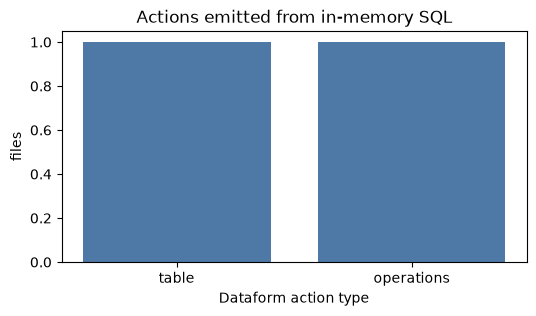

In [6]:
counts = result.report.actions_by_type
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(counts.keys(), counts.values(), color="#4E79A7")
ax.set_title("Actions emitted from in-memory SQL")
ax.set_ylabel("files")
ax.set_xlabel("Dataform action type")
plt.show()